#  Simulación de Marcha Cuadrúpeda Usando el Modelo de Kuramoto

Se importan las librerías necesarias.

In [9]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

Se definen los parámetros del sistema.

In [ ]:
N = 4  
omega = np.array([2.0] * N)
K = 1.2
A = 0.6
phi_0 = np.array([0.0, np.pi/2, np.pi, 3*np.pi/2])

Se implementa el sistema de Kuramoto.

In [10]:
def kuramoto(t, phi):
    dphi_dt = np.zeros(N)
    for i in range(N):
        dphi_dt[i] = omega[i] + (K / N) * sum(np.sin(phi[j] - phi[i]) for j in range(N))
    return dphi_dt

Se realiza la integración del sistema en el tiempo.

In [11]:
tiempo_total = 10
dt = 0.01
t_eval = np.arange(0, tiempo_total, dt)
sol = solve_ivp(kuramoto, [0, tiempo_total], phi_0, t_eval=t_eval, method='RK45')
fases = sol.y % (2*np.pi)

Se calculan los angulos articulares y centro de masa.

In [12]:
angulos = A * np.sin(fases)
centro_masa = np.mean(angulos, axis=0)

## Gráfico de fases de marcha

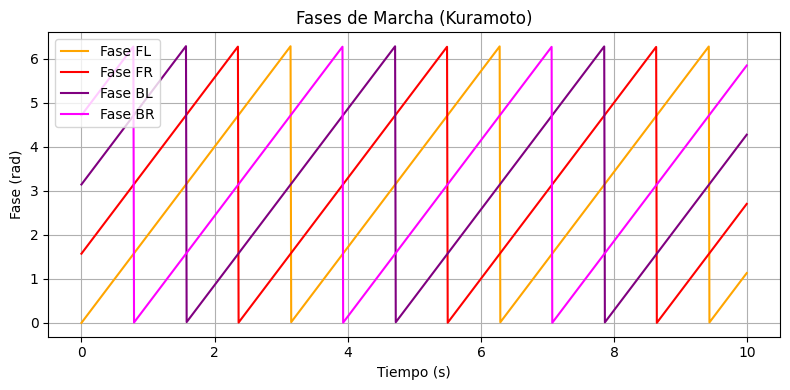

In [13]:
plt.figure(figsize=(8, 4))
plt.plot(sol.t, fases[0], label='Fase FL', color='orange')
plt.plot(sol.t, fases[1], label='Fase FR', color='red')
plt.plot(sol.t, fases[2], label='Fase BL', color='purple')
plt.plot(sol.t, fases[3], label='Fase BR', color='magenta')
plt.title('Fases de Marcha (Kuramoto)')
plt.xlabel('Tiempo (s)')
plt.ylabel('Fase (rad)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Grafico de ángulos articulares

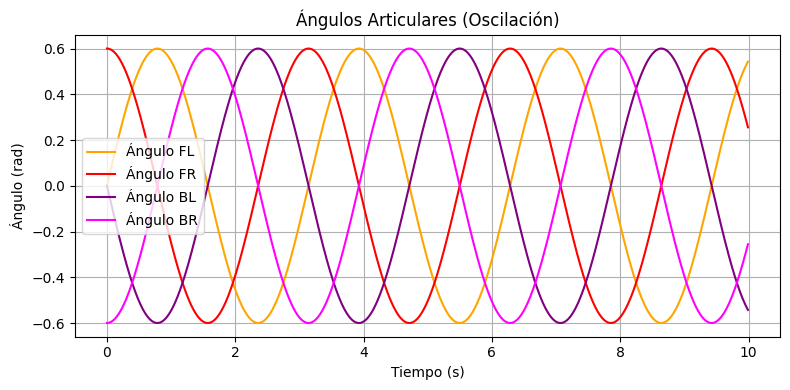

In [14]:
plt.figure(figsize=(8, 4))
plt.plot(sol.t, angulos[0], label='Ángulo FL', color='orange')
plt.plot(sol.t, angulos[1], label='Ángulo FR', color='red')
plt.plot(sol.t, angulos[2], label='Ángulo BL', color='purple')
plt.plot(sol.t, angulos[3], label='Ángulo BR', color='magenta')
plt.title('Ángulos Articulares (Oscilación)')
plt.xlabel('Tiempo (s)')
plt.ylabel('Ángulo (rad)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Gráfico de trayectoria del centro de masa

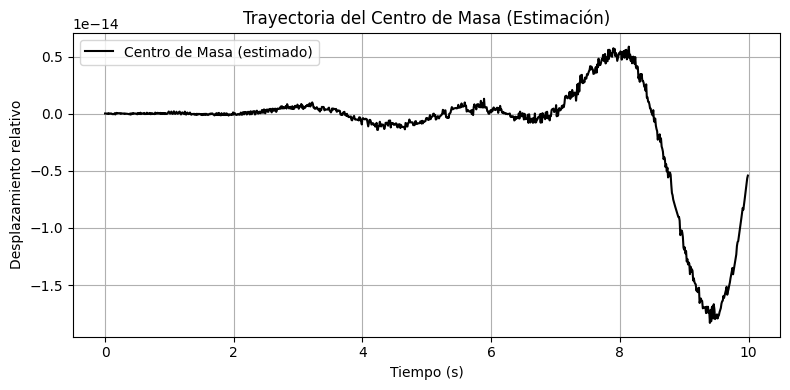

In [8]:
# 📊 8. Graficar Trayectoria del Centro de Masa
plt.figure(figsize=(8, 4))
plt.plot(sol.t, centro_masa, label='Centro de Masa (estimado)', color='black')
plt.title('Trayectoria del Centro de Masa (Estimación)')
plt.xlabel('Tiempo (s)')
plt.ylabel('Desplazamiento relativo')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()